In [1]:
import warnings
import copy

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import anndata as ad
import scanpy as sc
import pandas as pd
import math

In [ ]:
adata_b= sc.read_h5ad("/scratch/user/s4575250/BIOX7014_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_b_combined_annot_with_age_scvi.h5ad")

In [3]:
# Calculate proportions per donor with Age and Sex included
prop_df = (
    adata_b.obs.groupby(["pica_id", "Age", "Age_years", "Sex", "pica_cell_type_complete_01_gdT_corrected"])
    .size()
    .reset_index(name="count")
)

# Get total cells per donor
total = adata_b.obs.groupby("pica_id").size().reset_index(name="total")
prop_df = prop_df.merge(total, on="pica_id")
prop_df["Proportion"] = prop_df["count"] / prop_df["total"]

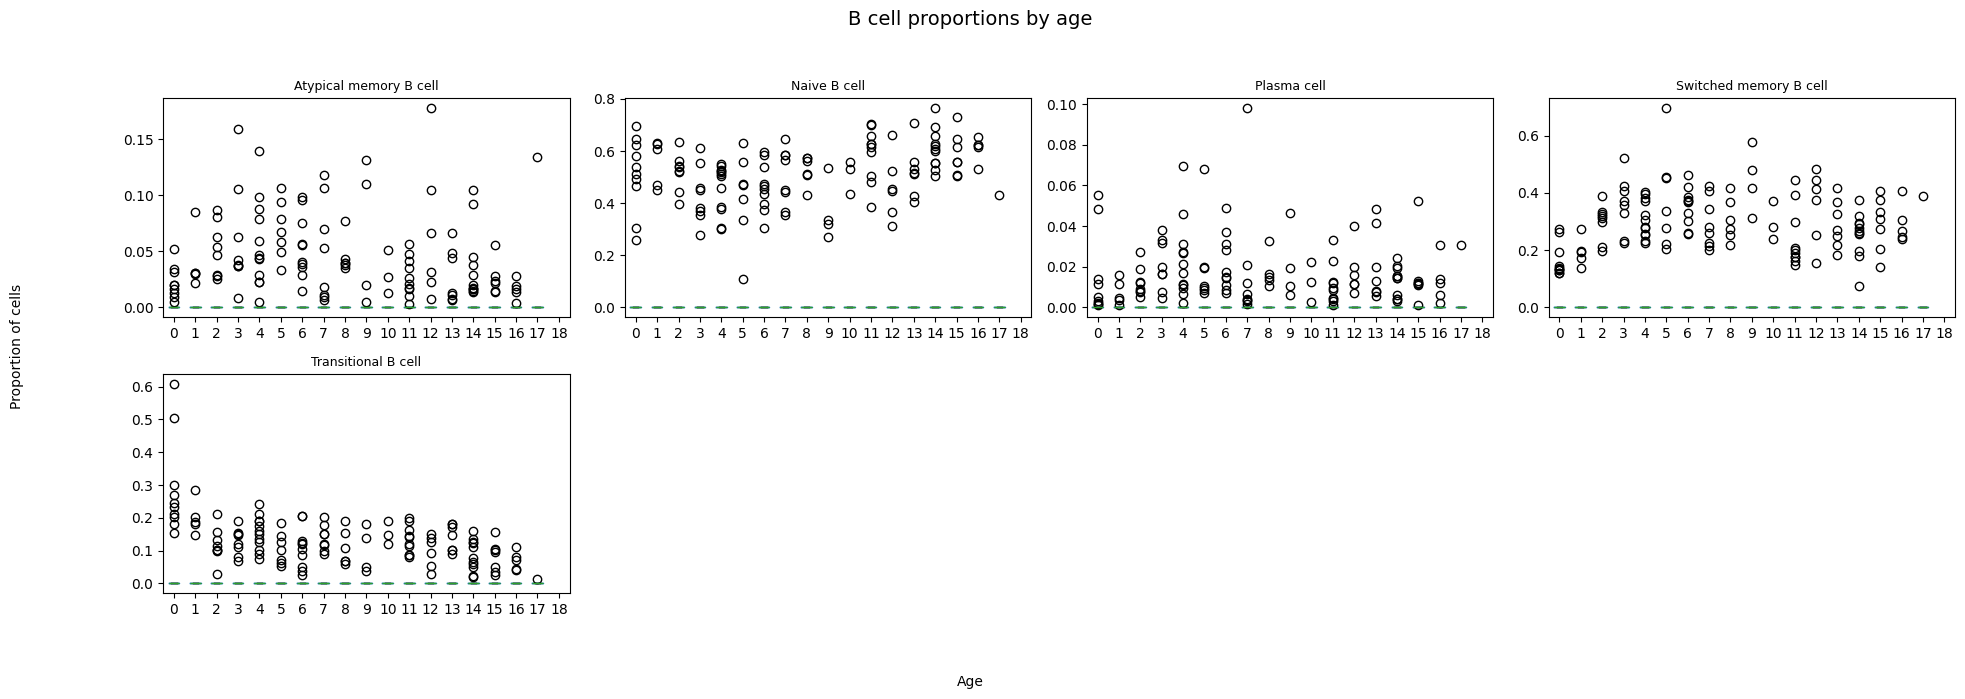

In [4]:
cell_types = sorted(prop_df["pica_cell_type_complete_01_gdT_corrected"].unique())

n_cols = 4
n_rows = math.ceil(len(cell_types) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for ax, cell in zip(axes, cell_types):
    sub = prop_df[prop_df["pica_cell_type_complete_01_gdT_corrected"] == cell]
    sub.boxplot(column="Proportion", by="Age", grid=False, ax=ax)  # capital P
    ax.set_xticks(range(1, 20))
    ax.set_xticklabels(range(0, 19))
    ax.set_xlim(0.5, 19.5)
    ax.set_title(cell, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[len(cell_types):]:
    ax.axis("off")

plt.suptitle("B cell proportions by age", fontsize=14)
fig.supxlabel("Age", fontsize=10)
fig.supylabel("Proportion of cells", fontsize=10)
plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
plt.show()